In [1]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Exploratory Data Analysis

## Loading Dataset

In [2]:
path_a = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_path_a = os.path.join(path_a, "creditcard.csv")
df_a = pd.read_csv(csv_path_a)

## Basic Inspection

In [3]:
print("Dataset shape:", df_a.shape)
print("\nData types:\n", df_a.dtypes)
print("\nNumber of duplicate rows:", df_a.duplicated().sum())
print("\nClass Distributions:", df_a["Class"].value_counts())

Dataset shape: (284807, 31)

Data types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Number of duplicate rows: 1081

Class Distributions: Class
0    284315
1       492
Name: count, dtype: int64


## Missing Values

In [4]:
print("Number of missing values:")
print(df_a.isnull().sum())

Number of missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## Distribution Analysis

### Dataset A

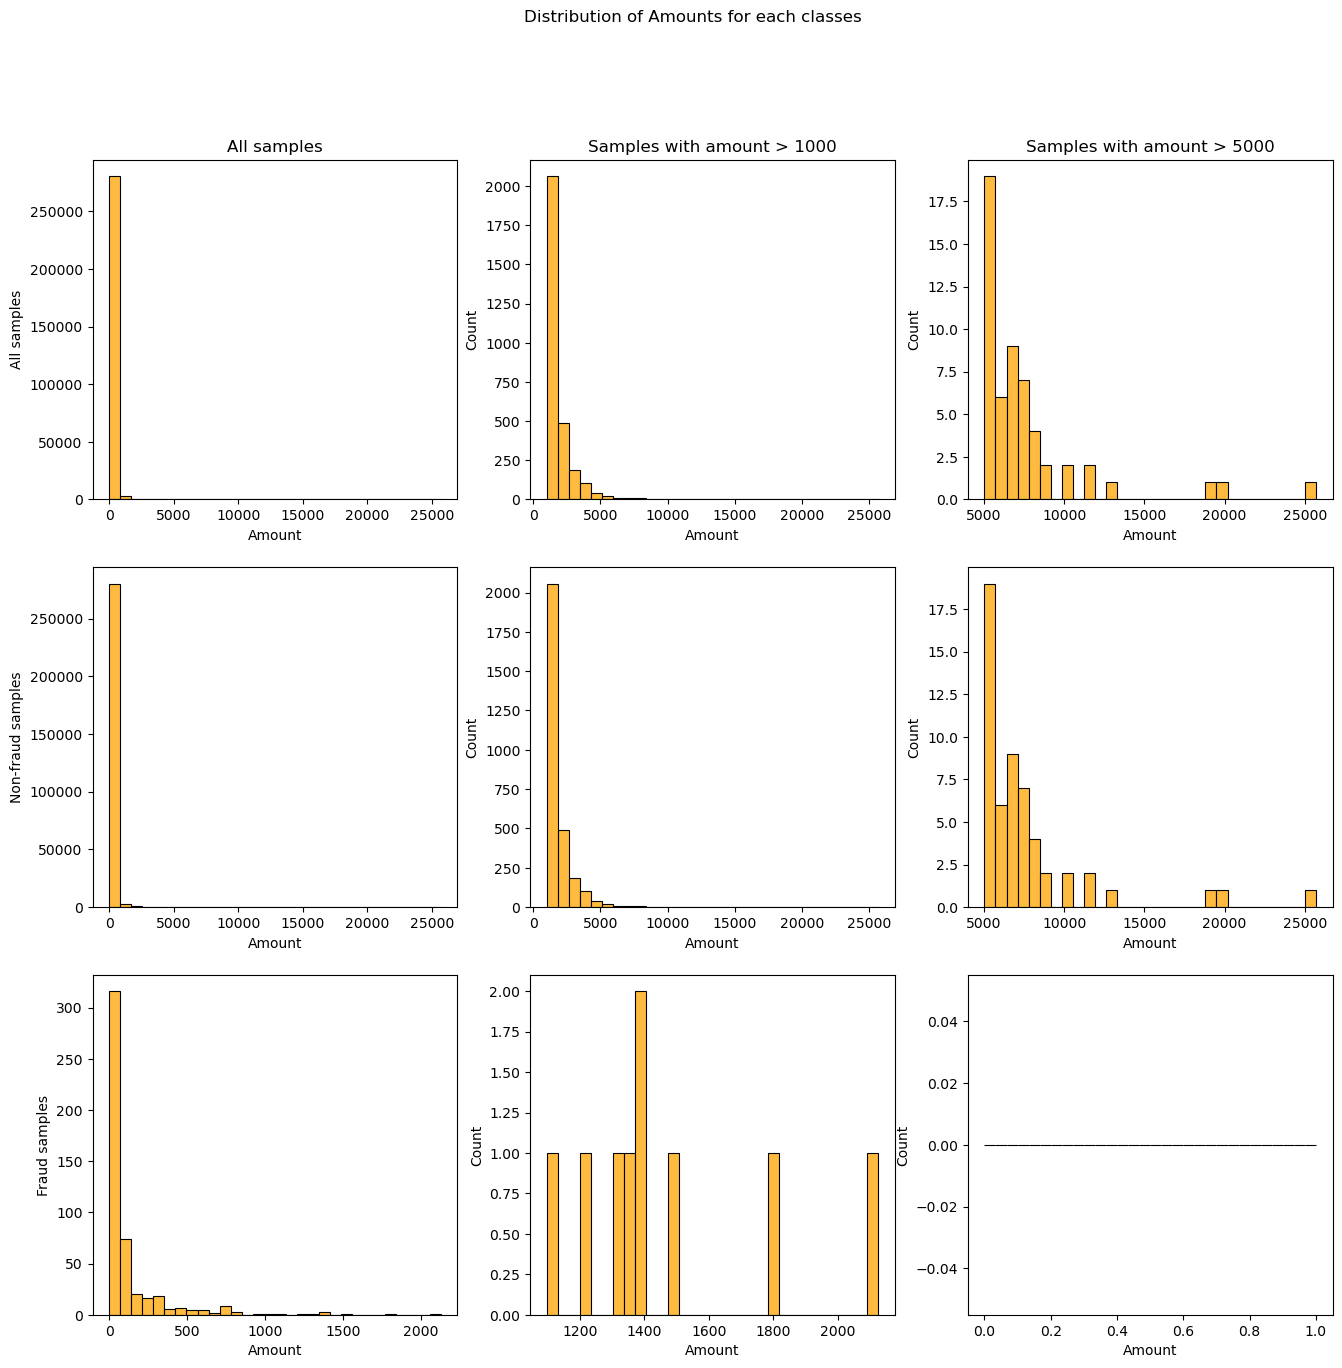

In [5]:
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(16, 15))
df_a_safe = df_a[df_a["Class"] == 0]
df_a_fraud = df_a[df_a["Class"] == 1]
crt_col = 0

for df in [df_a, df_a_safe, df_a_fraud]:
    df_a_1000 = df[df["Amount"] > 1000]
    df_a_5000 = df[df["Amount"] > 5000]

    sns.histplot(data=df, x="Amount", color="orange", bins=30, ax=axs[crt_col][0])
    sns.histplot(data=df_a_1000, x="Amount", color="orange", bins=30, ax=axs[crt_col][1])
    sns.histplot(data=df_a_5000, x="Amount", color="orange", bins=30, ax=axs[crt_col][2])

    crt_col += 1

axs[0, 0].set_title("All samples")
axs[0, 1].set_title("Samples with amount > 1000")
axs[0, 2].set_title("Samples with amount > 5000")

axs[0, 0].set_ylabel("All samples")
axs[1, 0].set_ylabel("Non-fraud samples")
axs[2, 0].set_ylabel("Fraud samples")

fig.suptitle("Distribution of Amounts for each classes")
plt.show()

Transaction amount has extreme right-skew.

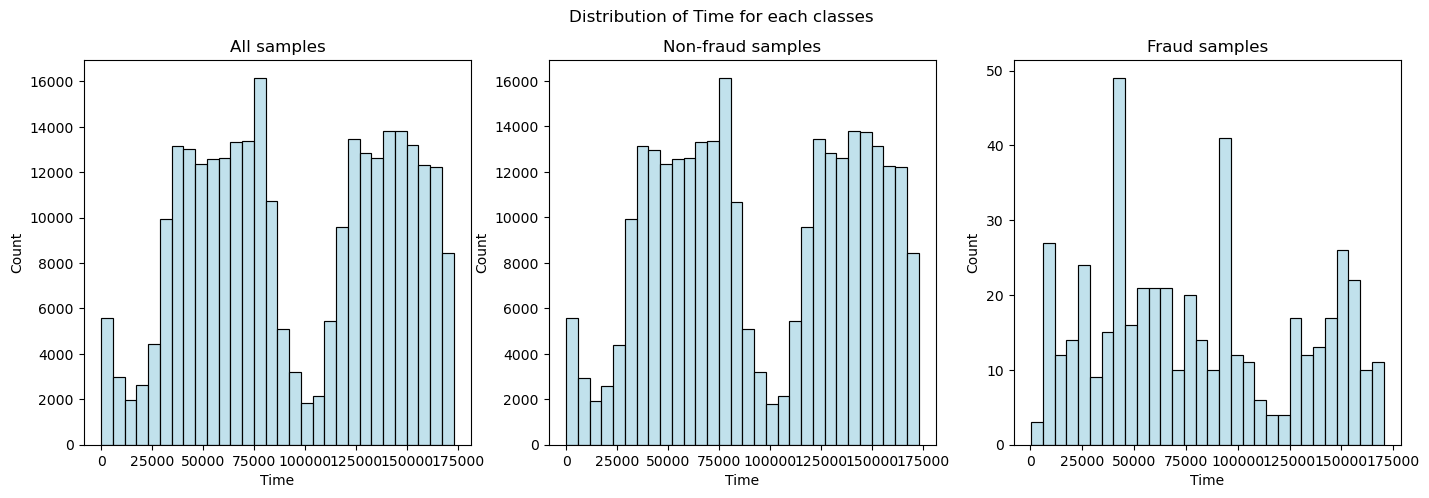

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(17, 5))
i = 0

for df in [df_a, df_a_safe, df_a_fraud]:
    sns.histplot(data=df, x="Time", color="lightblue", bins=30, ax=axs[i])
    i += 1
    
axs[0].set_title("All samples")
axs[1].set_title("Non-fraud samples")
axs[2].set_title("Fraud samples")
    
fig.suptitle("Distribution of Time for each classes")
plt.show()

## Correlation Analysis

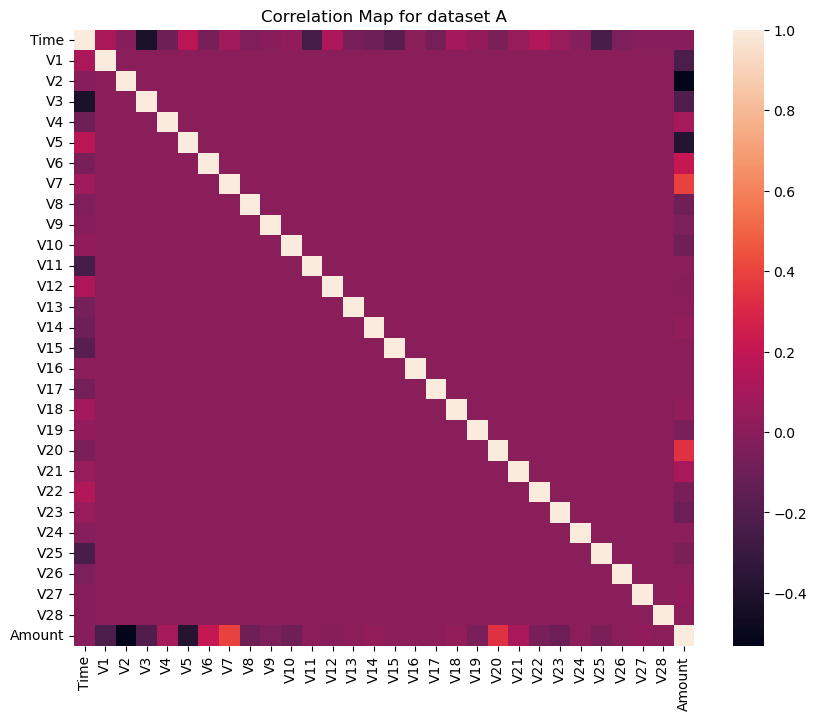

In [7]:
df_a_numeric = df_a.select_dtypes(include=[np.number]).iloc[:, :-1]
df_a_corr = df_a_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_a_corr)
plt.title("Correlation Map for dataset A")
plt.show()

No features are highly coorelated with each other. Therefore, dimentionality reduction is not needed.

## Outlier Detection

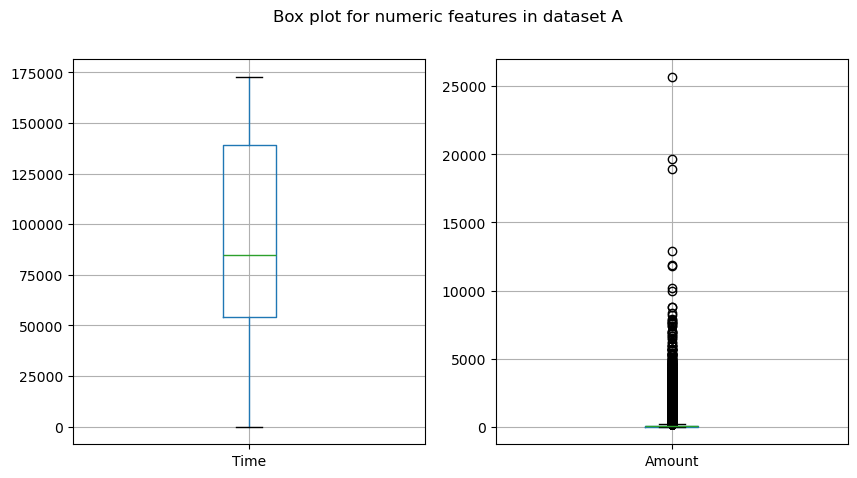

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
i = 0

for feat in ["Time", "Amount"]:
    df_a.boxplot(column=[feat], ax = axs[i])
    i += 1
    
fig.suptitle("Box plot for numeric features in dataset A")
plt.show()

Due to extremely high skew, there are many "outliers" for transaction amount. Since these outlier values represent legitimate transaction behavior rather than data errors, they will be retained. Some transformations may need to be applied to reduce skewness and improve model stability for the "Amount" feature.

# Preprocessing

In [9]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as sk_Pipeline

## Preprocessing pipeline for Dataset A

In [10]:
def log_transform(X):
    """
    Apply log(1 + x) for column with significant skews
    """
    return np.log1p(X)

In [11]:
log_transformer_pipeline_a = sk_Pipeline(steps=[
    ("log", FunctionTransformer(log_transform)),
    ("std", StandardScaler())
])

# Log transformer for "Amount" to handle right skew
# StandardScalar to "Amount" and "Time"
# Remain PCA components untouched
processor_a = ColumnTransformer(
    transformers=[
        ("log", log_transformer_pipeline_a, ["Amount"]),
        ("std", StandardScaler(), ["Time"]),
    ],
    remainder="passthrough"
)

In [12]:
Xa = df_a.iloc[:, :-1]
ya = df_a.iloc[:, -1]

In [13]:
Xa_processed = processor_a.fit_transform(Xa)
print(Xa.iloc[0, :].to_numpy())
print(Xa_processed[0])

[ 0.00000000e+00 -1.35980713e+00 -7.27811733e-02  2.53634674e+00
  1.37815522e+00 -3.38320770e-01  4.62387778e-01  2.39598554e-01
  9.86979013e-02  3.63786970e-01  9.07941720e-02 -5.51599533e-01
 -6.17800856e-01 -9.91389847e-01 -3.11169354e-01  1.46817697e+00
 -4.70400525e-01  2.07971242e-01  2.57905802e-02  4.03992960e-01
  2.51412098e-01 -1.83067779e-02  2.77837576e-01 -1.10473910e-01
  6.69280749e-02  1.28539358e-01 -1.89114844e-01  1.33558377e-01
 -2.10530535e-02  1.49620000e+02]
[ 1.12430334 -1.99658302 -1.35980713 -0.07278117  2.53634674  1.37815522
 -0.33832077  0.46238778  0.23959855  0.0986979   0.36378697  0.09079417
 -0.55159953 -0.61780086 -0.99138985 -0.31116935  1.46817697 -0.47040053
  0.20797124  0.02579058  0.40399296  0.2514121  -0.01830678  0.27783758
 -0.11047391  0.06692807  0.12853936 -0.18911484  0.13355838 -0.02105305]


# Train-Valid-Test Split

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
Xa_train, Xa_test, ya_train, ya_test = train_test_split(Xa, ya, test_size=0.2, stratify=ya, random_state=42)

# Check the class distribution for training and testing data
print("Length of A =", len(ya))
print("Length of A Train =", len(ya_train))
print("Length of A Test =", len(ya_test))
print()
print("Distribution for A =", np.mean(ya))
print("Distribution for A Train =", np.mean(ya_train))
print("Distribution for A Test =", np.mean(ya_test))

Length of A = 284807
Length of A Train = 227845
Length of A Test = 56962

Distribution for A = 0.001727485630620034
Distribution for A Train = 0.001729245759178389
Distribution for A Test = 0.0017204452090867595


# Cross-Validation Framework

In [16]:
from sklearn.model_selection import StratifiedKFold

## Dataset A

In [17]:
# 5-fold CV for dataset A
k = 5
skf_a = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

print("Original:")
print("Length of A =", len(ya_train))
print("Distribution for A =", np.mean(ya_train))
print()
print("Testign CV splits inside the training set")

for i, (train_idx, valid_idx) in enumerate(skf_a.split(Xa_train, ya_train)):
    X_train = Xa_train.iloc[train_idx]
    X_valid = Xa_train.iloc[valid_idx]
    y_train = ya_train.iloc[train_idx]
    y_valid = ya_train.iloc[valid_idx]

    print(f"Fold {i + 1}:")
    print()
    print("Length of A Train =", len(y_train))
    print("Length of A Valid =", len(y_valid))
    print()
    print("Distribution for A Train =", np.mean(y_train))
    print("Distribution for A Valid =", np.mean(y_valid))
    print()

Original:
Length of A = 227845
Distribution for A = 0.001729245759178389

Testign CV splits inside the training set
Fold 1:

Length of A Train = 182276
Length of A Valid = 45569

Distribution for A Train = 0.0017336347078057452
Distribution for A Valid = 0.0017116899646689636

Fold 2:

Length of A Train = 182276
Length of A Valid = 45569

Distribution for A Train = 0.0017281485220215498
Distribution for A Valid = 0.0017336347078057452

Fold 3:

Length of A Train = 182276
Length of A Valid = 45569

Distribution for A Train = 0.0017281485220215498
Distribution for A Valid = 0.0017336347078057452

Fold 4:

Length of A Train = 182276
Length of A Valid = 45569

Distribution for A Train = 0.0017281485220215498
Distribution for A Valid = 0.0017336347078057452

Fold 5:

Length of A Train = 182276
Length of A Valid = 45569

Distribution for A Train = 0.0017281485220215498
Distribution for A Valid = 0.0017336347078057452



# Pipeline

In [18]:
# Uncomment and run below cell to install imblearn

In [19]:
# pip install imbalanced-learn

In [20]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imb_Pipeline

In [21]:
def classifier_pipeline_a(model):
    """
    Get classification pipeline for dataset A with given model
    """
    pipeline = imb_Pipeline([
        ("transform", processor_a),
        ("smote", SMOTE(random_state=42)),
        ("classification", model)
    ])

    return pipeline

In [22]:
print("Testing that SMOTE will generate samples so that class distributions will be balanced")
print("Before SMOTE:")
print("Length of A Train =", len(ya))
print("Distribution for A Train =", np.mean(ya))
print()

Xa_smote, ya_smote = SMOTE().fit_resample(Xa_processed, ya)

print("After SMOTE:")
print("Length of A Train =", len(ya_smote))
print("Distribution for A Train =", np.mean(ya_smote))

Testing that SMOTE will generate samples so that class distributions will be balanced
Before SMOTE:
Length of A Train = 284807
Distribution for A Train = 0.001727485630620034

After SMOTE:
Length of A Train = 568630
Distribution for A Train = 0.5


# Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate

In [24]:
def get_metrics(y_true, y_pred):
    """
    Compute accuracy, precision, recall, f1, and roc_auc for given classification.
    """
    list_metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    list_metrics = [accuracy_score, precision_score, recall_score, f1_score, roc_auc_score]
    dict_metrics = dict()

    for metric_name, metric in zip(list_metric_names, list_metrics):
        score = metric(y_true, y_pred)
        dict_metrics[metric_name] = score

    return dict_metrics

In [25]:
def evaluate(model, X, y, score="probability"):
    """
    Evaluate performance on the model by predicting X and compare it to y.
    Return "accuracy", "precision", "recall", "f1" and "roc_auc" by dictionary.
    Also return predictions and scores.
    """
    y_pred = model.predict(X)

    if score =="probability":
        y_score = model.predict_proba(X)[:, 1]
    elif score == "decision":
        y_score = model.decision_function(X)

    dict_this_metrics = get_metrics(y, y_pred)

    return dict_this_metrics, y_pred, y_score

In [26]:
def evaluate_cv(pipeline, X, y, cv, score="probability", print_itr=False):
    """
    Measure performance of the pipeline by Cross-Validation and 
    report its "accuracy", "precision", "recall", "f1" and "roc_auc".
    Score is measured using "predict_proba", but will use "decision_function" if score="decision".
    Also return all y validation set and probability prediction set for precision_recall_curve. 
    Also return confusion matrix of all validations during cv.
    """
    list_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    list_y_val = list()
    list_probs = list()
    list_y_pred = list()
    dict_metrics = dict()
    dict_training = dict()
    fold = 0

    for metric in list_metrics:
        dict_metrics[metric] = list()
        dict_training[metric] = list()

    for train_idx, val_idx in cv.split(X, y):
        if print_itr:
            print("Fold", fold)
            fold += 1
        
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]
        
        pipeline.fit(X_train, y_train)
        dict_this_metrics, y_pred, probs = evaluate(pipeline, X_val, y_val, score)
        dict_this_training, _, _ = evaluate(pipeline, X_train, y_train, score)

        for metric in list_metrics:
            dict_metrics[metric].append(dict_this_metrics[metric])
            dict_training[metric].append(dict_this_training[metric])
        
        list_y_val.extend(y_val)
        list_probs.extend(probs)
        list_y_pred.extend(y_pred)

    for metric in list_metrics:
        scores = dict_metrics[metric]
        training_score = np.mean(dict_training[metric]).item()
        mean_score = np.mean(scores).item()
        std_score = np.std(scores).item()
        dict_metrics[metric] = np.round(np.array([training_score, mean_score, std_score]), 3)
    
    df_metric = pd.DataFrame(dict_metrics).transpose()
    df_metric.columns = ["training mean", "validation mean", "validation std"]
    cm = confusion_matrix(list_y_val, list_y_pred)
    
    return df_metric, list_y_val, list_probs, cm

## Dataset a

In [27]:
pipeline_a1 = classifier_pipeline_a(LogisticRegression())
df_metric_lr, list_val_lr, list_score_lr, cm_lr = evaluate_cv(pipeline_a1, Xa_train, ya_train, skf_a)
df_metric_lr

,training mean,validation mean,validation std
accuracy,0.974,0.974,0.002
precision,0.058,0.057,0.002
recall,0.928,0.904,0.023
f1,0.110,0.107,0.004
roc_auc,0.951,0.939,0.011


In [28]:
def plot_curves(list_y_val, list_y_score):
    """
    Plot Precision-Recall Curve and ROC curve for given true list of y and list of probabilities.
    """
    precision, recall, _ = precision_recall_curve(list_y_val, list_y_score)
    fpr, tpr, _ = roc_curve(list_y_val, list_y_score)
    
    fig, axs = plt.subplots(ncols=2, figsize=(10, 4))
    
    axs[0].plot(recall, precision)
    axs[0].set_xlabel("Recall")
    axs[0].set_ylabel("Precision")
    axs[0].set_title("Precision-Recall Curve")
    
    axs[1].plot(fpr, tpr)
    axs[1].plot([0, 1], [0, 1], "k--")
    axs[1].set_xlabel("False Positive Rate")
    axs[1].set_ylabel("True Positive Rate")
    axs[1].set_title("ROC Curve")
    
    plt.show()

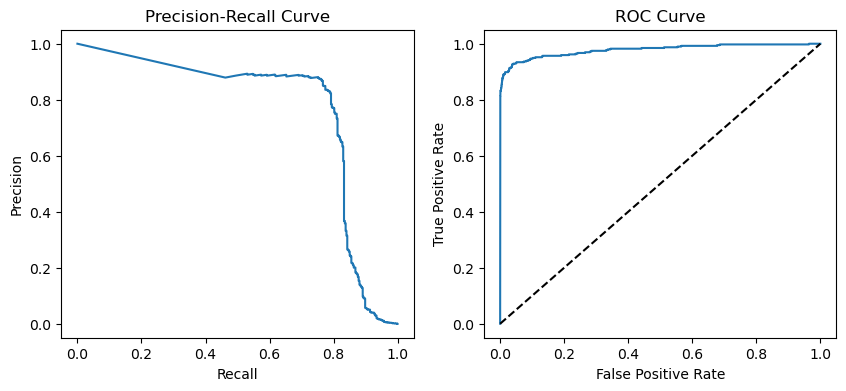

In [29]:
plot_curves(list_val_lr, list_score_lr)

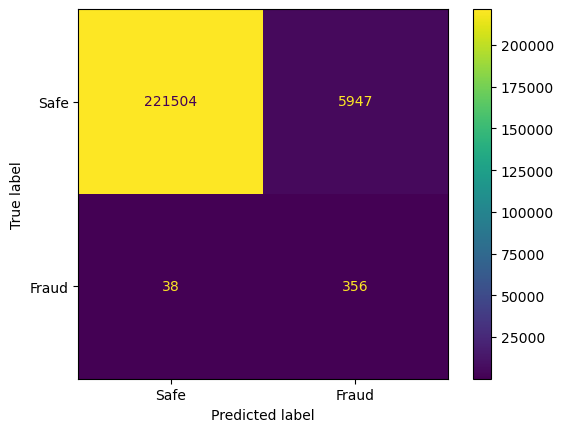

In [30]:
cm_disp = ConfusionMatrixDisplay(cm_lr, display_labels=["Safe", "Fraud"])
cm_disp.plot()
plt.show()

- The baseline model has high average recall of around 0.9. 
- According to the confusion matrix, around 30 out of 344 fraud samples are incorrectly classified as safe. 
- According to the precision-recall curve, in order to accurately detect fraud samples, we must make some incorrect classification of safe samples as fraud. 

# SVM

In [31]:
from sklearn import svm
from sklearn.model_selection import cross_val_score

## Hyperparameter Tuning

Because the number of data is huge, SVM and RF are very slow. So, we have decided to train it using subset of default training samples. Because of the significant imbalance between classes, we will keep all fraud samples in the training set but only select 10000 non-fraud set randomly. This allow us to reduce the training time for these models while preserving the class imbalance. 

In [32]:
def drop_data(X, y, n_safe_data):
    """
    Reduce number of non-fraud samples to given size, while maintaining all fraud samples.
    """
    non_fraud_idx = np.where(y == 0)
    fraud_idx = np.where(y == 1)

    selected_safe_idx = np.random.choice(non_fraud_idx[0], n_safe_data, replace=False)
    selected_idx = np.hstack((fraud_idx[0], selected_safe_idx))

    return X.iloc[selected_idx], y.iloc[selected_idx]

In [33]:
# Reduce and train only on sub-sample of the data.
Xa_dropped_svm, ya_dropped_svm = drop_data(Xa_train, ya_train, 10000)

In [34]:
list_C = [0.1, 1, 10]
list_gamma = ["scale", 0.01, 0.1]
list_params = list()
list_scores = list()

for C in list_C:
    for gamma in list_gamma:
        print(f"Training SVC(C={C}, gamma={gamma})")
        classifier = svm.SVC(kernel="rbf", C=C, gamma=gamma)
        pipeline_svm = classifier_pipeline_a(classifier)

        # Temporary 3-Fold object just for CV training process.
        cv_3fold = StratifiedKFold(n_splits=3, shuffle=True)
        
        # Compare "Recall" of model.
        recall = cross_val_score(pipeline_svm, Xa_dropped_svm, ya_dropped_svm, cv=cv_3fold, scoring="recall")
        list_params.append((C, gamma))
        list_scores.append(np.mean(recall).item())

params_idx = np.argmax(list_scores)
optimal_C, optimal_gamma = list_params[params_idx]
print()
print("Optimal C =", optimal_C)
print("Optimal gamma =", optimal_gamma)

Training SVC(C=0.1, gamma=scale)
Training SVC(C=0.1, gamma=0.01)
Training SVC(C=0.1, gamma=0.1)
Training SVC(C=1, gamma=scale)
Training SVC(C=1, gamma=0.01)
Training SVC(C=1, gamma=0.1)
Training SVC(C=10, gamma=scale)
Training SVC(C=10, gamma=0.01)
Training SVC(C=10, gamma=0.1)

Optimal C = 0.1
Optimal gamma = 0.1


## Evaluation

In [35]:
classifier_svm = svm.SVC(kernel="rbf", C=optimal_C, gamma=optimal_gamma)
pipeline_svm = classifier_pipeline_a(classifier_svm)
df_metric_svm, list_val_svm, list_score_svm, cm_svm = evaluate_cv(pipeline_svm, Xa_dropped_svm, ya_dropped_svm, skf_a, score="decision")
df_metric_svm

,training mean,validation mean,validation std
accuracy,0.959,0.942,0.004
precision,0.479,0.390,0.017
recall,0.987,0.926,0.017
f1,0.645,0.549,0.018
roc_auc,0.973,0.935,0.009


Although there were only slight improvement in average recall, there was a huge improvement in precision compared to the baseline. Also, these seem to be stable across folds, as standard deviation of them across the fold was lower than that of the baseline LR model. 

# Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
Xa_dropped_rf, ya_dropped_rf = drop_data(Xa_train, ya_train, 20000)

In [38]:
list_n_estimators = [50, 100]
list_max_depth = [10, 20]
list_min_samples_leaf = [1, 5, 10]
list_params = list()
list_scores = list()

for n_estimators in list_n_estimators:
    for max_depth in list_max_depth:
        for min_samples_leaf in list_min_samples_leaf:
            print(f"Training RF(n_estimators={n_estimators}, max_depth={max_depth}, min_samples_leaf={min_samples_leaf})")
            classifier = RandomForestClassifier(n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, n_jobs=-1, random_state=42)
            pipeline_rf = classifier_pipeline_a(classifier)

            # Compare "Recall" of model.
            recall = cross_val_score(pipeline_rf, Xa_dropped_rf, ya_dropped_rf, cv=skf_a, scoring="recall")
            list_scores.append(np.mean(recall).item())
            list_params.append((n_estimators, max_depth, min_samples_leaf))

params_idx = np.argmax(list_scores)
n_estimators_opt, max_depth_opt, min_samples_leaf_opt = list_params[params_idx]
print()
print("Optimal # estimators =", n_estimators_opt)
print("Optimal max depth =", max_depth_opt)
print("Optimal min samples leaf =", min_samples_leaf_opt)

Training RF(n_estimators=50, max_depth=10, min_samples_leaf=1)
Training RF(n_estimators=50, max_depth=10, min_samples_leaf=5)
Training RF(n_estimators=50, max_depth=10, min_samples_leaf=10)
Training RF(n_estimators=50, max_depth=20, min_samples_leaf=1)
Training RF(n_estimators=50, max_depth=20, min_samples_leaf=5)
Training RF(n_estimators=50, max_depth=20, min_samples_leaf=10)
Training RF(n_estimators=100, max_depth=10, min_samples_leaf=1)
Training RF(n_estimators=100, max_depth=10, min_samples_leaf=5)
Training RF(n_estimators=100, max_depth=10, min_samples_leaf=10)
Training RF(n_estimators=100, max_depth=20, min_samples_leaf=1)
Training RF(n_estimators=100, max_depth=20, min_samples_leaf=5)
Training RF(n_estimators=100, max_depth=20, min_samples_leaf=10)

Optimal # estimators = 50
Optimal max depth = 10
Optimal min samples leaf = 10


In [39]:
classifier_rf = RandomForestClassifier(n_estimators_opt, max_depth=max_depth_opt, min_samples_leaf=min_samples_leaf_opt, n_jobs=-1, random_state=42)
pipeline_rf = classifier_pipeline_a(classifier_rf)
df_metric_rf, list_val_rf, list_score_rf, cm_rf = evaluate_cv(pipeline_rf, Xa_dropped_rf, ya_dropped_rf, skf_a)
df_metric_rf

,training mean,validation mean,validation std
accuracy,0.997,0.994,0.001
precision,0.890,0.823,0.041
recall,0.993,0.866,0.023
f1,0.938,0.843,0.019
roc_auc,0.995,0.931,0.011


RF had significant improvement on the average precisions. However, average recall has dropped. Also, some metrics were not stable across folds, since they had relatively higher standard deviations compared to other models. 

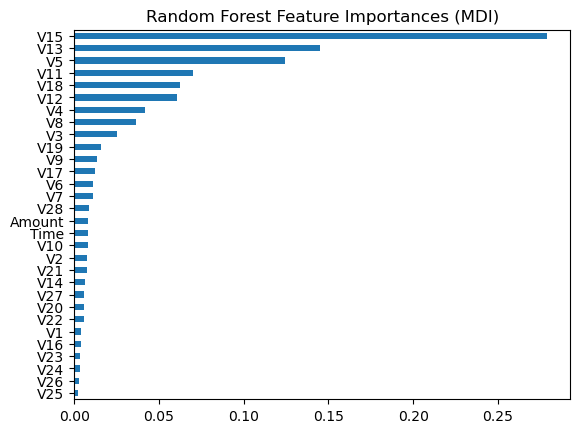

In [40]:
feature_imp = classifier_rf.feature_importances_
series_imp = pd.Series(feature_imp, index=Xa_dropped_rf.columns).sort_values()

series_imp.plot(kind="barh")
plt.title("Random Forest Feature Importances (MDI)")
plt.show()

A small subset of latent features, such as V15, V13 and V5 has showed high importance according to the importance plot. This means that PCA has extracted few latent features which makes big contributions in the fraud detection. However, non-latent features, time and amount, had little importance, suggesting that fraud is not really determined by these features. 

# Model Comparison

## Compareing mean CV metrics for all three models

In [41]:
dict_mean_cv = dict()
dict_mean_cv["Logistic Regression"] = df_metric_lr.loc[:, "validation mean"]
dict_mean_cv["SVM"] = df_metric_svm.loc[:, "validation mean"]
dict_mean_cv["Random Forest"] = df_metric_rf.loc[:, "validation mean"]

df_mean_cv = pd.DataFrame(dict_mean_cv).transpose()
df_mean_cv.columns = df_metric_lr.index
df_mean_cv

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.974,0.057,0.904,0.107,0.939
SVM,0.942,0.390,0.926,0.549,0.935
Random Forest,0.994,0.823,0.866,0.843,0.931


Because of the huge imbalance in data, models will predict “non-fraud” for most of the time. Therefore, accuracy metric is useless. Also, in this case, missing fraud case is far more critical than false alarm, F1-score, the metric which treats false positives and false negatives equally, is meaningless here as well. Since the goal of this project is to accurately detect fraud while minimizing false positives, so our objective is to maximize the recall while maintain reasonable precision. When comparing recall of each models, SVM has highest recall of 0.93, while Random Forest has lowest recall of 0.87. When comparing precisions, Random Forest has highest precision of 0.88, Logistic Regression has poor precision of 0.06, while SVM has low, but relatively stable precision compared to Logistic Regression model. Therefore, Logistic Regression accurately detects fraud, but has way too many false positives, Random Forest model is very precise but misses fraud, and SVM model is best in detecting fraud while being most precise in its prediction. 

## Confusion martices

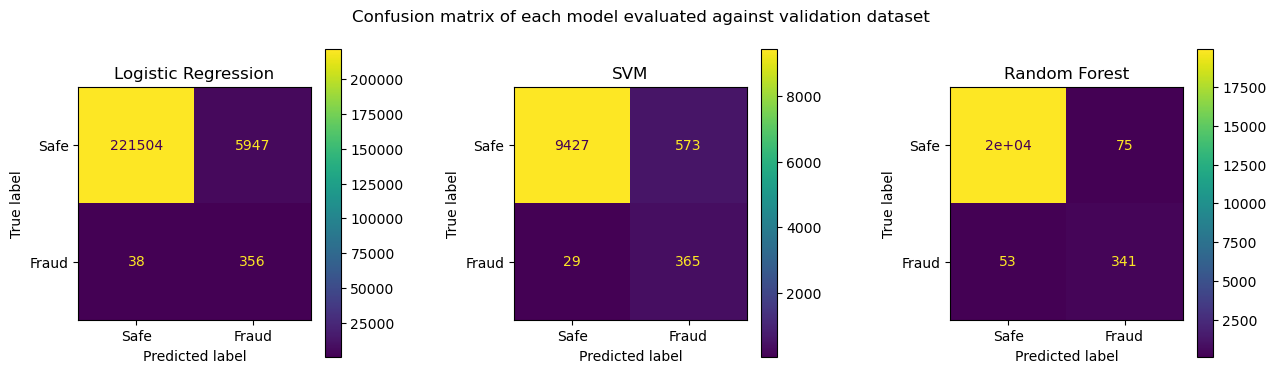

In [42]:
list_cm = [cm_lr, cm_svm, cm_rf]
fig, axs = plt.subplots(ncols=3, figsize=(15, 4))
list_model_names = ["Logistic Regression", "SVM", "Random Forest"]

for i, cm in enumerate(list_cm):
    cm_disp = ConfusionMatrixDisplay(cm, display_labels=["Safe", "Fraud"])
    cm_disp.plot(ax=axs[i])
    axs[i].set_title(list_model_names[i])

plt.suptitle("Confusion matrix of each model evaluated against validation dataset")
plt.subplots_adjust(wspace=0.5)
plt.show()

Even SVM and Random Forest are trained and evaluated with cross validation using reduced dataset, all fraud samples are kept, so numbers in lower half of confusion matrix have same meanings. As shown here, Random Forest model makes most misclassification on fraud sample while SVM model most accurately detects fraud samples even when trained with reduced dataset. 

## Precision-Recall Trade Off

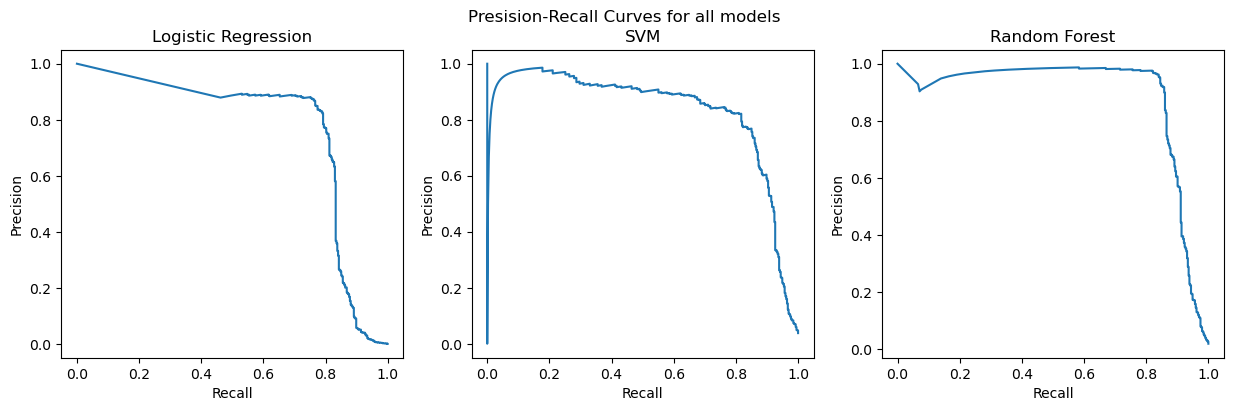

In [43]:
list_valid = [list_val_lr, list_val_svm, list_val_rf]
list_scores = [list_score_lr, list_score_svm, list_score_rf]
fig, axs = plt.subplots(ncols=3, figsize=(15, 4))

for i in range(3):
    precision, recall, _ = precision_recall_curve(list_valid[i], list_scores[i])
    axs[i].plot(recall, precision)
    axs[i].set_xlabel("Recall")
    axs[i].set_ylabel("Precision")
    axs[i].set_title(list_model_names[i])

plt.suptitle("Presision-Recall Curves for all models")
plt.show()

According to the precision-recall plot, in order to accurately detect fraud transactions using Logistic Regression model, it must make lot of false positives. While for other two models, they seems to be able to maintain relatively high precision for high recall. 

### Variance of CV metrics for each models (Recall)

In [44]:
list_df_metrics = [df_metric_lr, df_metric_svm, df_metric_rf]
dict_vars = dict()

for metric_name, df_metrics in zip(list_model_names, list_df_metrics):
    mean = df_metrics.loc["recall", "validation mean"]
    std = df_metrics.loc["recall", "validation std"]
    ratio = std / mean
    dict_vars[metric_name] = np.round(np.array([mean, std, ratio]), 3)

df_vars = pd.DataFrame(dict_vars).transpose()
df_vars.columns = ["Mean", "Standard Deviation", "Relative Std"]
df_vars

,Mean,Standard Deviation,Relative Std
Logistic Regression,0.904,0.023,0.025
SVM,0.926,0.017,0.018
Random Forest,0.866,0.023,0.027


According to the table of each models’ mean recall and their standard deviations across the cross-validation folds, SVM model seems to be most consistently achieving high recall, while for Random Forest model, it not only has lower recall, but also have relatively unstable prediction. 

## Overfitting Check

In [45]:
list_df_metrics = [df_metric_lr, df_metric_svm, df_metric_rf]
dict_tr_var = dict()

for metric_name, df_metrics in zip(list_model_names, list_df_metrics):
    recall_tr = df_metrics.loc["recall", "training mean"]
    recall_val = df_metrics.loc["recall", "validation mean"]
    dict_tr_var[metric_name] = [recall_tr, recall_val]

df_tr_var = pd.DataFrame(dict_tr_var).transpose()
df_tr_var.columns = ["Training Recall", "Validation Recall"]
df_tr_var

,Training Recall,Validation Recall
Logistic Regression,0.928,0.904
SVM,0.987,0.926
Random Forest,0.993,0.866


According to the table, Random Forest has almost perfectly detected fraud samples for training set but significantly lower score for validation set. This shows large gap between training and validation scores, indicates overfitting in the model. In contrast, other two models demonstrated better generalization with smaller gap between performance on training and validation dataset, with high recall score for validation dataset on SVM model. 

## Final Decision

### WINNER: SVM model

Among three models, we have concluded that SVM model is the most effective in detecting fraud in transactions with achieving highest recall while maintaining moderate false positive rates. In this context, correctly detecting fraud transactions is far more important than incorrectly classifying safe transactions as fraud. So although Random Forest model achieved highest accuracy, precision, and F1-scores, we have decided that it is not the best choice for fraud detection tasks because of its low recall, lack of stability in performance, and evidence of overfitting. In contrast, SVM model demonstrated its ability to accurately detect fraud detection while being stable in its performance, making it best model for fraud detection. 

## Tuning decision threshold

Final SVM model was trained on entire reduced training dataset, and evaluated against test set. It achieved high recall of 0.93. However, although SVM model observed moderate precision score during evaluation phase, the test precision score dropped significantly to 0.03. 

This issue arises because the model was trained on a dataset that was balanced by SMOTE, which shifts the decision boundary towards the minority class. The CV precision did not drop because CV was performed using reduced dataset which is more balanced than the original. However, the test set preserves original class imbalance. As a result, the final model produced a large number of false positives. 

To address this, decision threshold tuning was introduced, allowing better control over the precision-recall trade-off. Decision thresholds were optimized using a cost-sensitive framework, where each misclassification were assigned unequal costs, and the optimal threshold was selected by minimizing total expected cost over validation predictions. In this case, false negative are assumed to be 100 times more expensive than false positive, since missing fraud samples is far more critical. 


In [46]:
def optimal_thres_bycost(y_true, y_score, cost_fp, cost_fn):
    """
    Find optimal threshold which minimizes the cost.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    list_costs = list()

    for t in thresholds:
        y_pred = [1 if yi_score >= t else 0 for yi_score in y_score]
        num_fp = 0
        num_fn = 0

        for yi_pred, yi_true in zip(y_pred, y_true):
            if yi_pred == 1 and yi_true == 0:
                num_fp += 1
            elif yi_pred == 0 and yi_true == 1:
                num_fn += 1

        cost = cost_fp * num_fp + cost_fn * num_fn
        list_costs.append(cost)

    return list_costs, thresholds

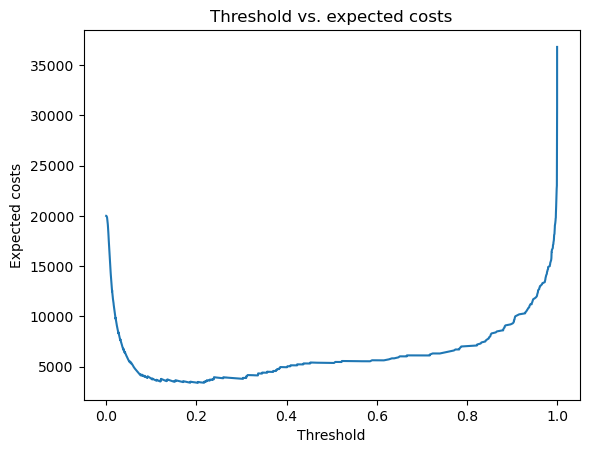

In [47]:
cost_fp = 1
cost_fn = 100
list_costs, thresholds = optimal_thres_bycost(list_val_rf, list_score_rf, cost_fp, cost_fn)

plt.plot(thresholds, list_costs)
plt.title("Threshold vs. expected costs")
plt.xlabel("Threshold")
plt.ylabel("Expected costs")
plt.show()

In [48]:
min_idx = np.argmin(list_costs)
opt_threshold = thresholds[min_idx]
print(opt_threshold)

0.2031292203264215


However, the cost-based threshold tuning resulted in an optimal decision boundary of -0.08, which is close to the default decision boundary, 0. As a result, minimal change in performance metrics was observed. 

# Final Result

In [56]:
final_model = RandomForestClassifier(n_estimators_opt, max_depth=max_depth_opt, min_samples_leaf=min_samples_leaf_opt, n_jobs=-1, random_state=42)
pipeline_final = classifier_pipeline_a(final_model)
pipeline_final.fit(Xa_dropped_rf, ya_dropped_rf)
ya_score_final = pipeline_final.predict_proba(Xa_test)[:, 1]

In [57]:
ya_pred_final = [1 if yi_score >= opt_threshold else 0 for yi_score in ya_score_final]
dict_metrics_final = get_metrics(ya_test, ya_pred_final)
print(dict_metrics_final)

{'accuracy': 0.959499315333029, 'precision': 0.0384454659423318, 'recall': 0.9387755102040817, 'f1': 0.07386591730228824, 'roc_auc': 0.9491552705775614}


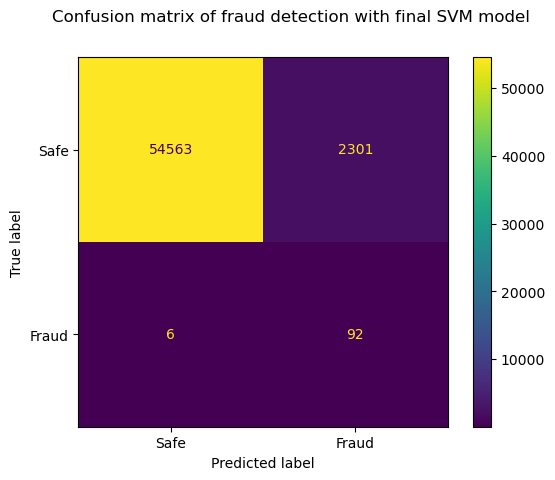

In [58]:
cm_final = confusion_matrix(ya_test, ya_pred_final)
cm_disp_final = ConfusionMatrixDisplay(cm_final, display_labels=["Safe", "Fraud"])
cm_disp_final.plot()

plt.suptitle("Confusion matrix of fraud detection with final SVM model")
plt.show()